# Test de normalisation — `TelemacDataset`

Ce notebook vérifie que la **normalisation** appliquée par votre dataset (fichier `python/create_dgl_dataset.py`) est correcte :
- mapping des **indices** (one-hot, strickler, z, h, u, v),
- cohérence des **statistiques** (moyennes/écarts-types) calculées,
- centrage/réduction de **x dynamiques** (`h,u,v`), de **targets** (`Δh, Δu, Δv`) et des **features d'arêtes**,
- non-normalisation du **one-hot**,
- cohérence **train** vs **eval** (utilisation des stats sauvegardées).

In [1]:
import os 
import sys
project_path = os.path.abspath(os.path.join(os.getcwd(), '..', ''))
sys.path.append(project_path)
from python.create_dgl_dataset import TelemacDataset,load_json,add_mesh_info
from python.python_code.data_manip.extraction.telemac_file import TelemacFile


In [2]:
# Imports du repo
import os, json
import torch
import dgl
import numpy as np
from pprint import pprint

In [3]:
GLOBAL_DIR =  "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/"

In [4]:
DATA_DIR = GLOBAL_DIR+'Mesh8_base.bin'
mesh_list = [GLOBAL_DIR+'Mesh8_corrige.slf']

DYNAMIC_FILES = [
GLOBAL_DIR+"Group_1_peak_1000_Group_1_peak_1000_0_0-80_interpolated.pkl",
GLOBAL_DIR+"Group_1_peak_1200_Group_1_peak_1200_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_1400_Group_1_peak_1400_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_1600_Group_1_peak_1600_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_1800_Group_1_peak_1800_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_2000_Group_1_peak_2000_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_2200_Group_1_peak_2200_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_2400_Group_1_peak_2400_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_2600_Group_1_peak_2600_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_2800_Group_1_peak_2800_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_3000_Group_1_peak_3000_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_3200_Group_1_peak_3200_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_3400_Group_1_peak_3400_0_0-80_interpolated.pkl",
#GLOBAL_DIR+"Group_1_peak_3600_Group_1_peak_3600_0_0-80_interpolated.pkl",

]

In [5]:
CKPT_DIR = "./test/ckpt_norm_tests"  # dossier où seront sauvegardées/chargées les stats
SEQUENCE_LENGTH = 1             
OVERLAP = 1
BATCH_SIZE = 1

In [6]:
!ls ./test/ckpt_norm_tests

edge_stats.json  node_stats.json


In [7]:
!rm -rf ./test/ckpt_norm_tests

In [8]:
!ls ./test/ckpt_norm_tests

ls: cannot access './test/ckpt_norm_tests': No such file or directory


In [9]:
assert isinstance(DYNAMIC_FILES, list) and len(DYNAMIC_FILES) > 0, "Renseignez au moins 1 fichier .pkl dans DYNAMIC_FILES"

## 1) Chargement du dataset — `split='train'` (calcul + sauvegarde des stats)

In [10]:
# Chargement train : calcule et SAUVEGARDE les stats (node_stats.json / edge_stats.json)
train_set = TelemacDataset(
    name="telemac_train",
    data_dir=DATA_DIR,
    dynamic_data_files=DYNAMIC_FILES,
    split="train",
    ckpt_path=CKPT_DIR,
    normalize=True,
    sequence_length=SEQUENCE_LENGTH,
    overlap=OVERLAP,
)

print(f"Nombre de séquences (train): {len(train_set)}")
print("Clés node_stats: ", list(train_set.node_stats.keys()))
print("Clés edge_stats: ", list(train_set.edge_stats.keys()))

Normalizing data...
Nombre de séquences (train): 62
Clés node_stats:  ['h', 'u', 'v', 'strickler', 'z', 'delta_h', 'delta_u', 'delta_v', 'strickler_std', 'z_std', 'h_std', 'u_std', 'v_std', 'delta_h_std', 'delta_u_std', 'delta_v_std']
Clés edge_stats:  ['xrel', 'yrel', 'norm', 'xrel_std', 'yrel_std', 'norm_std']


## 2) Vérification du **mapping des indices** (one-hot, strickler, z, h, u, v)

Le dataset concatène : `x = [onehot(4), strickler, z, h, u, v]` ⇒ indices `0..8`.

In [11]:
# Récupère un batch (séquence) et inspecte les colonnes
seq = train_set[0]  # liste de graphs (longueur = SEQUENCE_LENGTH)
g0 = seq[0]

x = g0.ndata['x']
print("x shape:", x.shape)
print("Aperçu des 3 premières lignes de x:")
print(x[:3, :])

# Quick checks
onehot = x[:, :4]
strickler = x[:, 4:5]
z = x[:, 5:6]
dyn = x[:, 6:9]  # h,u,v

print("onehot row sums (devraient valoir 1):", onehot.sum(dim=1)[:5])
print("Indices dynamiques [6:9] -> h,u,v, shape:", dyn.shape)

x shape: torch.Size([16222, 9])
Aperçu des 3 premières lignes de x:
tensor([[ 0.0000,  0.0000,  0.0000,  1.0000, -0.9288,  2.3940, -0.3517, -0.3101,
         -0.1507],
        [ 0.0000,  0.0000,  0.0000,  1.0000, -0.0258,  2.6413, -0.3517, -0.3101,
         -0.1507],
        [ 0.0000,  0.0000,  0.0000,  1.0000, -0.0258,  2.2963, -0.3517, -0.3101,
         -0.1507]])
onehot row sums (devraient valoir 1): tensor([1., 1., 1., 1., 1.])
Indices dynamiques [6:9] -> h,u,v, shape: torch.Size([16222, 3])


## 3) Vérifier les **stats** et la **normalisation**

- `node_stats.json` / `edge_stats.json` sauvegardés dans `CKPT_DIR`.
- On recalcule des stats **empiriques** sur le dataset normalisé pour vérifier que `mean≈0`, `std≈1` (par variable normalisée).


In [12]:
# Charge les stats sauvegardées (pour comparaison/affichage)
node_stats = load_json(os.path.join(CKPT_DIR, "node_stats.json"))
edge_stats = load_json(os.path.join(CKPT_DIR, "edge_stats.json"))

print("=== node_stats (extraits) ===")
for k in ["h","u","v","delta_h","delta_u","delta_v","strickler","z"]:
    print(k, "-> mean:", float(node_stats[k]), " std:", float(node_stats[f"{k}_std"]))

print("\n=== edge_stats ===")
pprint({k: float(edge_stats[k]) for k in edge_stats if not k.endswith("_std")})
pprint({k: float(edge_stats[k]) for k in edge_stats if k.endswith("_std")})

=== node_stats (extraits) ===
h -> mean: 0.38455697894096375  std: 1.0932743549346924
u -> mean: 0.16041436791419983  std: 0.5172215104103088
v -> mean: 0.03198205307126045  std: 0.21226133406162262
delta_h -> mean: 0.0035633821971714497  std: 0.03938056156039238
delta_u -> mean: 0.0012431084178388119  std: 0.02147391065955162
delta_v -> mean: 0.00025129341520369053  std: 0.014184233732521534
strickler -> mean: 20.285612106323242  std: 11.073880195617676
z -> mean: 17.808265686035156  std: 13.680917739868164

=== edge_stats ===
{'norm': 81.02482604980469, 'xrel': 0.0, 'yrel': 0.0}
{'norm_std': 80.57962799072266,
 'xrel_std': 80.89105987548828,
 'yrel_std': 80.71390533447266}


In [13]:
def check_global_stats_with_static(ds, max_batches=500, atol_mean=5e-3, atol_std=5e-2):
    # ----- STATIC CHECKS -----
    static = ds.base_graph.ndata['static'].cpu().numpy()
    assert static.shape[1] >= 6, f"Static has {static.shape[1]} cols, expected >=6 (node_type[4], strickler, z)"
    node_type = static[:, :4]
    strickler = static[:, 4]
    z = static[:, 5]

    # node_type one-hot: values 0/1 and exactly one 1 per row
    node_type_ok_vals = np.all((node_type == 0) | (node_type == 1))
    rowsums = node_type.sum(axis=1)
    node_type_ok_rows = np.all(rowsums == 1)
    print(f"STATIC node_type values 0/1: {node_type_ok_vals}")
    print(f"STATIC node_type one-hot rows (sum==1): {node_type_ok_rows} "
          f"(min sum={rowsums.min()}, max sum={rowsums.max()})")

    # strickler / z normalized: mean≈0, std≈1
    strickler_mean, strickler_std = strickler.mean(), strickler.std()
    z_mean, z_std = z.mean(), z.std()
    print(f"STATIC strickler mean/std: {strickler_mean:.6f} / {strickler_std:.6f}")
    print(f"STATIC z         mean/std: {z_mean:.6f} / {z_std:.6f}")
    assert abs(strickler_mean) <= atol_mean and abs(strickler_std - 1.0) <= atol_std, \
        "Strickler not ~N(0,1) after normalization"
    assert abs(z_mean) <= atol_mean and abs(z_std - 1.0) <= atol_std, \
        "z not ~N(0,1) after normalization"

    # ----- DYNAMIC (GLOBAL) CHECKS -----
    dyn_off = static.shape[1]
    cnt_x = 0
    sum_x = np.zeros(3, dtype=np.float64); sumsq_x = np.zeros(3, dtype=np.float64)
    cnt_y = 0
    sum_y = np.zeros(3, dtype=np.float64); sumsq_y = np.zeros(3, dtype=np.float64)

    for seq_idx in range(min(len(ds), max_batches)):
        for g in ds[seq_idx]:
            x_dyn = g.ndata['x'][:, dyn_off:dyn_off+3].cpu().numpy()
            y = g.ndata['y'].cpu().numpy()
            sum_x += x_dyn.sum(axis=0); sumsq_x += (x_dyn * x_dyn).sum(axis=0); cnt_x += x_dyn.shape[0]
            sum_y += y.sum(axis=0);     sumsq_y += (y * y).sum(axis=0);         cnt_y += y.shape[0]

    mean_x = sum_x / cnt_x; var_x = sumsq_x / cnt_x - mean_x**2; std_x = np.sqrt(np.maximum(var_x, 0.0))
    mean_y = sum_y / cnt_y; var_y = sumsq_y / cnt_y - mean_y**2; std_y = np.sqrt(np.maximum(var_y, 0.0))

    print("GLOBAL x_dyn_mean:", mean_x)
    print("GLOBAL x_dyn_std :", std_x)
    print("GLOBAL y_mean    :", mean_y)
    print("GLOBAL y_std     :", std_y)

    # Optional: assert dynamic/targets are roughly standardized globally
    for i, lbl in enumerate(['h','u','v']):
        assert abs(mean_x[i]) <= 5*atol_mean and abs(std_x[i]-1) <= 5*atol_std, f"x_dyn[{lbl}] not ~N(0,1)"
    for i, lbl in enumerate(['dh','du','dv']):
        # targets can be looser depending on masking; relax a bit
        assert abs(mean_y[i]) <= 10*atol_mean and abs(std_y[i]-1) <= 10*atol_std, f"y[{lbl}] not ~N(0,1)"


check_global_stats_with_static(train_set)  


STATIC node_type values 0/1: True
STATIC node_type one-hot rows (sum==1): True (min sum=1.0, max sum=1.0)
STATIC strickler mean/std: -0.000000 / 1.000000
STATIC z         mean/std: 0.000000 / 1.000000
GLOBAL x_dyn_mean: [-4.55087547e-06  5.61790033e-08 -1.70338133e-06]
GLOBAL x_dyn_std : [1.00001681 0.99992352 0.99995449]
GLOBAL y_mean    : [-5.46981855e-06  9.83224297e-06  2.47912615e-06]
GLOBAL y_std     : [0.99997561 1.00000999 0.99997353]


**Interprétation attendue :**  
- `x_dyn_mean` ≈ `[0,0,0]`, `x_dyn_std` ≈ `[1,1,1]`  
- `x_stat_mean` ≈ `[0,0]`, `x_stat_std` ≈ `[1,1]`  
- `edge_mean` ≈ `[0,0,0]`, `edge_std` ≈ `[1,1,1]`  
- `y_mean` ≈ `[0,0,0]`, `y_std` ≈ `[1,1,1]`  

De petits écarts sont normaux (moyenne par graphe/échantillonage).


## 4) Vérifier que le **one-hot** n'est pas normalisé

In [14]:
oh = g0.ndata['x'][:, :4]
unique_rows = torch.unique(oh, dim=0)
print("One-hot unique rows:")
print(unique_rows)
assert torch.all((oh.sum(dim=1) - 1.0).abs() < 1e-6), "Le one-hot ne semble pas correct (somme != 1)"
print("OK: one-hot intact (non normalisé).")

One-hot unique rows:
tensor([[0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.]])
OK: one-hot intact (non normalisé).


## 5) Cohérence **train vs eval/test**

- En `train`, on **calcule** et **sauvegarde** les stats.  
- En `eval/test`, on **charge** ces stats depuis `CKPT_DIR` et on normalise avec les mêmes valeurs.  
On compare ici `node_stats`/`edge_stats` du dataset `eval` à ceux de `train`.

In [15]:
eval_set = TelemacDataset(
    name="telemac_eval",
    data_dir=DATA_DIR,
    dynamic_data_files=DYNAMIC_FILES,
    split="eval",
    ckpt_path=CKPT_DIR,
    normalize=True,
    sequence_length=SEQUENCE_LENGTH,
    overlap=OVERLAP,
)

def same_stats(a, b, keys):
    for k in keys:
        if not torch.allclose(a[k], b[k], atol=1e-8, rtol=0):
            print("Mismatch on key:", k, "train:", a[k].item(), "eval:", b[k].item())
            return False
    return True

node_keys = list(train_set.node_stats.keys())
edge_keys = list(train_set.edge_stats.keys())

print("Node stats identical train/eval ?",
      same_stats(train_set.node_stats, eval_set.node_stats, node_keys))

print("Edge stats identical train/eval ?",
      same_stats(train_set.edge_stats, eval_set.edge_stats, edge_keys))

Loading normalization statistics...
Node stats identical train/eval ? True
Edge stats identical train/eval ? True


## 6) Test de **round-trip** (dé-normalisation / re-normalisation)

On prend une ligne `(h,u,v)` normalisée → on **dé-normalise** avec `node_stats` → on **re-normalise** et on vérifie qu'on retrouve l'original.

In [16]:
def denorm(x_norm, means, stds):
    return x_norm * stds + means

def renorm(x, means, stds):
    return (x - means) / (stds + 1e-12)

means = torch.stack([train_set.node_stats["h"], train_set.node_stats["u"], train_set.node_stats["v"]], dim=0).view(1,3)
stds  = torch.stack([train_set.node_stats["h_std"], train_set.node_stats["u_std"], train_set.node_stats["v_std"]], dim=0).view(1,3)

row = g0.ndata['x'][:5, 6:9]  # 5 premières lignes, colonnes h,u,v normalisées
x_phys = denorm(row, means, stds)
x_back = renorm(x_phys, means, stds)

print("Max abs diff round-trip:", (row - x_back).abs().max().item())
assert (row - x_back).abs().max().item() < 5e-6, "Round-trip renorm/denorm trop imprécis"
print("OK: round-trip précis.")

Max abs diff round-trip: 0.0
OK: round-trip précis.


In [17]:
import pickle


SEQUENCE_LENGTH = 1
OVERLAP = 0

# ---- Dataset eval normalisé avec les stats sauvegardées (train) ----
eval_set = TelemacDataset(
    name="telemac_eval_2files",
    data_dir=DATA_DIR,                    # *_base.bin
    dynamic_data_files=DYNAMIC_FILES,     # exactement 2 pickles
    split="eval",
    ckpt_path=CKPT_DIR,                   # charge node_stats.json / edge_stats.json
    normalize=True,
    sequence_length=SEQUENCE_LENGTH,
    overlap=OVERLAP,
)

# ---- Helpers stats -> vecteurs (h,u,v) et (dh,du,dv) ----
def get_stats_vec(node_stats, names):
    means = torch.stack([node_stats[n] for n in names], dim=0).view(1, -1).cpu().numpy()
    stds  = torch.stack([node_stats[f"{n}_std"] for n in names], dim=0).view(1, -1).cpu().numpy()
    return means, stds

means_x, stds_x = get_stats_vec(eval_set.node_stats, ["h","u","v"])
means_y, stds_y = get_stats_vec(eval_set.node_stats, ["delta_h","delta_u","delta_v"])

# ---- Recréons l’indexation "sans mélange" (offsets par fichier) ----
def sequences_per_file(pkl_path, sequence_length, overlap):
    with open(pkl_path, 'rb') as f:
        dyn_data = pickle.load(f)              # liste [(x_raw, y_raw), ...]
    step = max(1, sequence_length - overlap)
    n_seq = max(0, len(dyn_data) - sequence_length + 1)
    # progression par "step"
    if step > 1:
        n_seq = (n_seq + step - 1) // step
    return n_seq, dyn_data, step

n_seq_A, raw_A, STEP_A = sequences_per_file(DYNAMIC_FILES[0], SEQUENCE_LENGTH, OVERLAP)
n_seq_B, raw_B, STEP_B = sequences_per_file(DYNAMIC_FILES[1], SEQUENCE_LENGTH, OVERLAP)
assert STEP_A == STEP_B, "STEP doit être identique pour les deux pickles"
STEP = STEP_A

offset_A = 0
offset_B = n_seq_A
assert len(eval_set) == n_seq_A + n_seq_B, "Le dataset a mélangé/échantillonné différemment"


# ---- Comparaison (par défaut on compare le dernier pas de chaque séquence) ----
def compare_seq(ds, raw_list, global_idx, local_start, seq_len, which_step=-1, atol=1e-6, rtol=1e-7):
    if which_step < 0:
        which_step = seq_len - 1
    graphs = ds[global_idx]
    g = graphs[which_step]

    dyn_off = ds.base_graph.ndata['static'].shape[1]

    # récupère normalisé depuis dataset
    Xn = g.ndata['x'][:, dyn_off:dyn_off+3].cpu().numpy()  # h,u,v normés
    Yn = g.ndata['y'][:, 0:3].cpu().numpy()                # dh,du,dv normés

    # dé-normalise via tes helpers
    X_back = denorm(Xn, means_x, stds_x)   # [N,3]
    Y_back = denorm(Yn, means_y, stds_y)   # [N,3]

    # récupère brut depuis pickle
    raw_x, raw_y = raw_list[local_start + which_step]      # x: [N,3], y: [N,3]
    X_raw = raw_x[:, 0:3]
    Y_raw = raw_y[:, 0:3]

    # erreurs
    dx = np.abs(X_back - X_raw)
    dy = np.abs(Y_back - Y_raw)
    okx = np.allclose(X_back, X_raw, atol=atol, rtol=rtol)
    oky = np.allclose(Y_back, Y_raw, atol=atol, rtol=rtol)

    print(f"[gidx {global_idx} | step {which_step}]  "
          f"max|Δx|={dx.max():.3e}  max|Δy|={dy.max():.3e}  -> match={okx and oky}")
    return okx and oky, dx.max(), dy.max()

# ---- Lancer quelques comparaisons sur A puis B (sans mélange) ----
print("\n=== Fichier A ===")
for k in range(min(3, n_seq_A)):  # 3 séquences en exemple
    gidx = offset_A + k
    local_start = k * STEP
    compare_seq(eval_set, raw_A, gidx, local_start, SEQUENCE_LENGTH)

print("\n=== Fichier B ===")
for k in range(min(3, n_seq_B)):
    gidx = offset_B + k
    local_start = k * STEP
    compare_seq(eval_set, raw_B, gidx, local_start, SEQUENCE_LENGTH)


Loading normalization statistics...

=== Fichier A ===
[gidx 0 | step 0]  max|Δx|=6.563e-07  max|Δy|=2.390e-08  -> match=True
[gidx 1 | step 0]  max|Δx|=6.184e-07  max|Δy|=2.133e-08  -> match=True
[gidx 2 | step 0]  max|Δx|=6.645e-07  max|Δy|=2.839e-08  -> match=True

=== Fichier B ===
[gidx 31 | step 0]  max|Δx|=6.459e-07  max|Δy|=2.740e-08  -> match=True
[gidx 32 | step 0]  max|Δx|=6.600e-07  max|Δy|=3.214e-08  -> match=True
[gidx 33 | step 0]  max|Δx|=6.504e-07  max|Δy|=2.823e-08  -> match=True


In [18]:
def next_step_identity_masked(raw_list, static_features, atol=1e-6, rtol=1e-7):
    node_type = static_features[:, :4]  # [N,4]
    is_NORMAL = np.all(node_type == np.array([1,0,0,0]), axis=1)
    is_H      = np.all(node_type == np.array([0,1,0,0]), axis=1)
    is_Q      = np.all(node_type == np.array([0,0,1,0]), axis=1)
    is_WALL   = np.all(node_type == np.array([0,0,0,1]), axis=1)

    mask_INT  = is_NORMAL | is_WALL   # ici, CL non re-imposées → identité doit tenir sur h,u,v

    rep = {
        "INT(h,u,v)": {"ok": True, "worst": 0.0},
        "H(u,v)":     {"ok": True, "worst": 0.0},
        "H(h)":       {"ok": True, "worst": 0.0},  # attendu FAIL (on documente)
        "Q(all)":     {"ok": True, "worst": 0.0},  # attendu FAIL (on documente)
    }

    for t in range(len(raw_list)-1):
        x_t, y_t   = raw_list[t]     # [N,3], [N,3]
        x_t1, _    = raw_list[t+1]   # déjà re-imposé avec t+2
        lhs = x_t[:, :3] + y_t[:, :3]  # ce qui a servi pour calculer y_t (courant → futur à t+1)

        # 1) Intérieur + murs: comparer lhs vs x_t1 sur (h,u,v)
        if mask_INT.any():
            dx = np.abs(lhs[mask_INT] - x_t1[mask_INT, :3])
            rep["INT(h,u,v)"]["worst"] = max(rep["INT(h,u,v)"]["worst"], float(dx.max()) if dx.size else 0.0)
            rep["INT(h,u,v)"]["ok"] &= np.allclose(lhs[mask_INT], x_t1[mask_INT, :3], atol=atol, rtol=rtol)

        # 2) H: h est imposé → au step t+1, h a été réaligné vers t+2, donc h va *naturellement* diverger.
        #    En revanche u,v doivent respecter l’identité.
        if is_H.any():
            # u,v
            dx_uv = np.abs(lhs[is_H, 1:3] - x_t1[is_H, 1:3])
            rep["H(u,v)"]["worst"] = max(rep["H(u,v)"]["worst"], float(dx_uv.max()) if dx_uv.size else 0.0)
            rep["H(u,v)"]["ok"] &= np.allclose(lhs[is_H, 1:3], x_t1[is_H, 1:3], atol=atol, rtol=rtol)

            # h (documente l’écart attendu)
            dx_h = np.abs(lhs[is_H, 0] - x_t1[is_H, 0])
            rep["H(h)"]["worst"] = max(rep["H(h)"]["worst"], float(dx_h.max()) if dx_h.size else 0.0)
            # on s'attend à False, donc ne touche pas "ok" (ou laisse-le à False si tu veux forcer)

        # 3) Q: toutes les composantes sont imposées → x_{t+1} du pickle a déjà été poussé vers t+2.
        #    L’identité ne peut pas être testée contre x_t1; on log juste l’écart.
        if is_Q.any():
            dx_q = np.abs(lhs[is_Q] - x_t1[is_Q, :3])
            rep["Q(all)"]["worst"] = max(rep["Q(all)"]["worst"], float(dx_q.max()) if dx_q.size else 0.0)
            # idem, on ne force pas "ok" ici car on sait que ça "échouera" par construction.

    return rep

static_features = eval_set.base_graph.ndata['static'].cpu().numpy()
rep_A = next_step_identity_masked(raw_A, static_features)
rep_B = next_step_identity_masked(raw_B, static_features)
print("A:", rep_A)
print("B:", rep_B)

A: {'INT(h,u,v)': {'ok': True, 'worst': 3.2839210684088016e-08}, 'H(u,v)': {'ok': True, 'worst': 1.2191286012392527e-11}, 'H(h)': {'ok': True, 'worst': 4.440892098500626e-16}, 'Q(all)': {'ok': True, 'worst': 0.14437666427596196}}
B: {'INT(h,u,v)': {'ok': True, 'worst': 6.899451832076409e-08}, 'H(u,v)': {'ok': True, 'worst': 3.9442284291077434e-11}, 'H(h)': {'ok': True, 'worst': 4.440892098500626e-16}, 'Q(all)': {'ok': True, 'worst': 0.15597706936557099}}


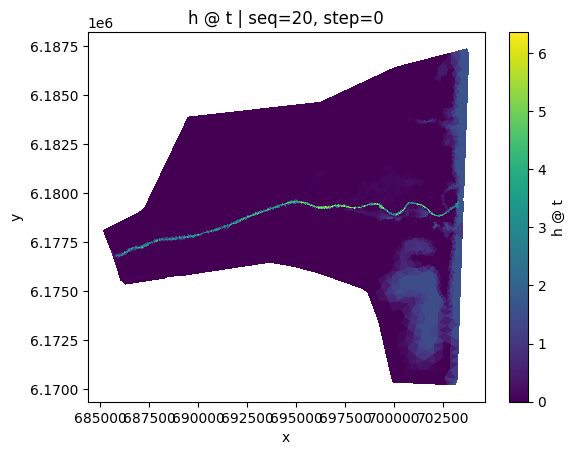

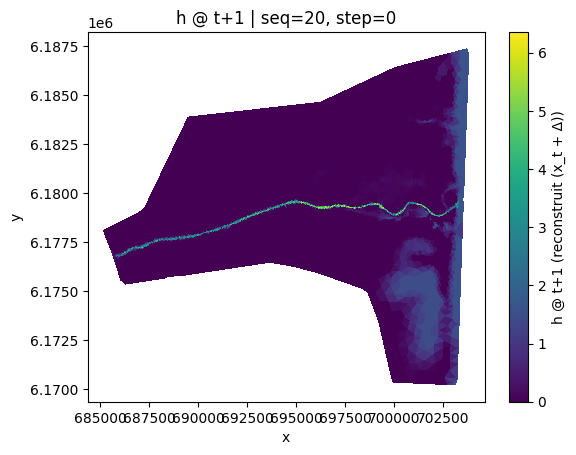

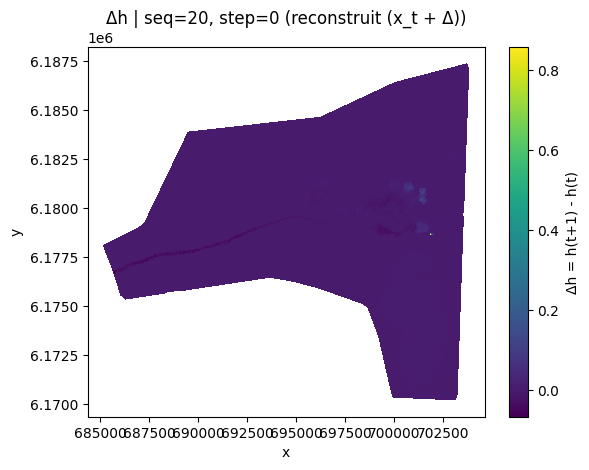

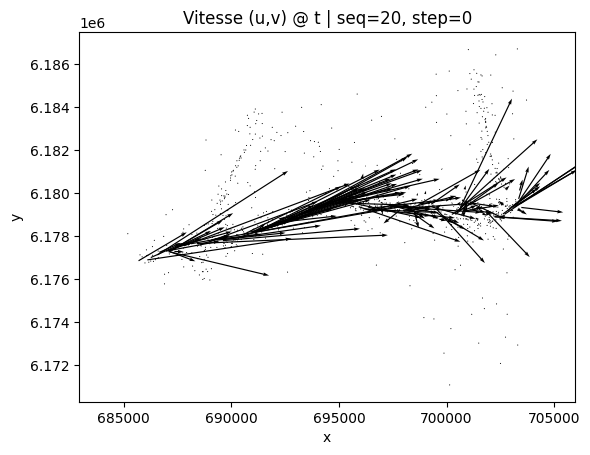

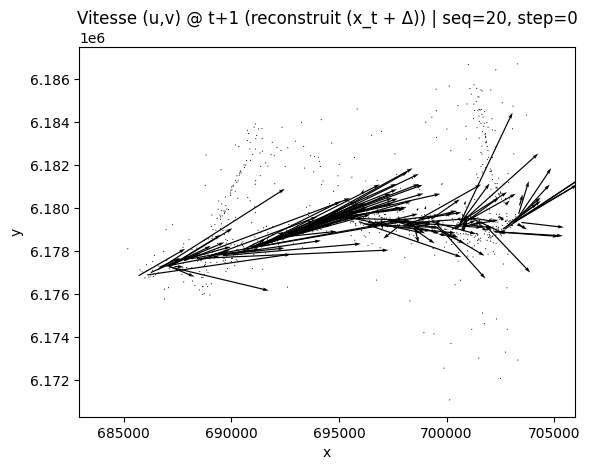

In [20]:
# === VISU "SUR LA MAP" SANS STOCKER POS DANS LE GRAPHE ===
import numpy as np
import matplotlib.pyplot as plt

# --------- PARAMS ----------
GLOBAL_IDX = 20     # séquence dans eval_set
T_STEP = 0         # pas t dans la séquence (si t+1 indisponible, on reconstruit via y)
SHOW_VELOCITY = True   # quiver (u,v)
TARGET_ARROWS = 1000     # quiver: nb approx de flèches

res_mesh = TelemacFile(mesh_list[0])

# --------- PRENDRE LE MAILLAGE DEPUIS res_mesh (ou MESH_PATH) ----------
try:
    res_mesh  # si déjà défini
except NameError:
    # Décommente si besoin :
    # from python.python_code.data_manip.extraction.telemac_file import TelemacFile
    # MESH_PATH = "ton/mesh.slf"
    # res_mesh = TelemacFile(MESH_PATH)
    raise RuntimeError("Définis d'abord `res_mesh = TelemacFile(MESH_PATH)` ou fournis MESH_PATH.")

# Récupère positions + triangles depuis le fichier maillage
pos, triangles = add_mesh_info(res_mesh)   # pos: np[N,2], triangles: np[M,3]
x, y = pos[:, 0], pos[:, 1]

# --------- HELPERS ----------
def stats_vec(node_stats, names):
    means = np.array([node_stats[n].item() for n in names], dtype=np.float32).reshape(1, -1)
    stds  = np.array([node_stats[f"{n}_std"].item() for n in names], dtype=np.float32).reshape(1, -1)
    return means, stds

def denorm(xn, means, stds):
    return xn * stds + means

def quiver_subset(x, y, u, v, target=300):
    every = max(1, int(len(x)/target))
    idx = np.arange(0, len(x), every, dtype=int)
    return x[idx], y[idx], u[idx], v[idx]

# --------- EXTRACTION DES DONNÉES (depuis eval_set) ----------
assert 'eval_set' in globals(), "Définis `eval_set` (TelemacDataset split='eval')."
graphs = eval_set[GLOBAL_IDX]
seq_len = len(graphs)

# colonnes dynamiques [h,u,v] se trouvent après les features statiques concaténées
dyn_off = eval_set.base_graph.ndata['static'].shape[1]

mx, sx = stats_vec(eval_set.node_stats, ["h","u","v"])
my, sy = stats_vec(eval_set.node_stats, ["delta_h","delta_u","delta_v"])

# @ t
g_t = graphs[T_STEP]
Xn_t = g_t.ndata['x'][:, dyn_off:dyn_off+3].cpu().numpy()  # [h,u,v] normalisés
X_t  = denorm(Xn_t, mx, sx)
h_t, u_t, v_t = X_t[:, 0], X_t[:, 1], X_t[:, 2]

# @ t+1 (direct si dispo, sinon reconstruit via Δ)
if T_STEP + 1 < seq_len:
    Xn_t1 = graphs[T_STEP + 1].ndata['x'][:, dyn_off:dyn_off+3].cpu().numpy()
    X_t1  = denorm(Xn_t1, mx, sx)
    src = "direct"
else:
    Yn_t = g_t.ndata['y'][:, :3].cpu().numpy()  # [dh,du,dv] normalisés
    Y_t  = denorm(Yn_t, my, sy)
    X_t1 = X_t + Y_t
    src = "reconstruit (x_t + Δ)"
h_t1, u_t1, v_t1 = X_t1[:, 0], X_t1[:, 1], X_t1[:, 2]

# Δh
dh = h_t1 - h_t

# --------- PLOTS SUR LA CARTE DU MAILLAGE (triangles du fichier) ----------
import matplotlib.tri as mtri
tri = mtri.Triangulation(x, y, triangles)

# h @ t
plt.figure()
pc = plt.tripcolor(tri, h_t, shading='flat')
plt.colorbar(pc, label="h @ t")
plt.title(f"h @ t | seq={GLOBAL_IDX}, step={T_STEP}")
plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
plt.show()

# h @ t+1
plt.figure()
pc = plt.tripcolor(tri, h_t1, shading='flat')
plt.colorbar(pc, label=f"h @ t+1 ({src})")
plt.title(f"h @ t+1 | seq={GLOBAL_IDX}, step={T_STEP}")
plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
plt.show()

# Δh
plt.figure()
pc = plt.tripcolor(tri, dh, shading='flat')
plt.colorbar(pc, label="Δh = h(t+1) - h(t)")
plt.title(f"Δh | seq={GLOBAL_IDX}, step={T_STEP} ({src})")
plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
plt.show()

# Quiver (u,v)
if SHOW_VELOCITY:
    plt.figure()
    xq, yq, uq, vq = quiver_subset(x, y, u_t, v_t, target=TARGET_ARROWS)
    plt.quiver(xq, yq, uq, vq, angles='xy', scale_units='xy')
    plt.title(f"Vitesse (u,v) @ t | seq={GLOBAL_IDX}, step={T_STEP}")
    plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
    plt.show()

    plt.figure()
    xq, yq, uq, vq = quiver_subset(x, y, u_t1, v_t1, target=TARGET_ARROWS)
    plt.quiver(xq, yq, uq, vq, angles='xy', scale_units='xy')
    plt.title(f"Vitesse (u,v) @ t+1 ({src}) | seq={GLOBAL_IDX}, step={T_STEP}")
    plt.xlabel("x"); plt.ylabel("y"); plt.axis('equal')
    plt.show()

